# Stability tests for the control system

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('font', family='sans-serif', serif='Computer Modern')
mpl.rc('text', usetex=True)
mpl.rc('font', size=12)

## Tests at Fixed voltage

In [2]:
filename = 'fixed_voltage_test.txt'
f = open(filename, 'r')  # Clear the file before writing
lines = [line.split(':') for line in f.readlines()]
f.close()

In [3]:
lines[0], lines[1], lines[2]

(['Vset expected  ', ' 2.52828 V\n'],
 ['Vdac measured  ', ' 2.48955 V\n'],
 ['Vset - Vdac    ', ' 0.03873 V\n'])

In [4]:
vset = []
vdac = []
for line in lines:
    if line[0] == 'Vset expected  ':
        vset.append(float(line[1].split('V')[0]))
    if line[0] == 'Vdac measured  ':
        vdac.append(float(line[1].split('V')[0]))
vdac = np.array(vdac)
vset = np.array(vset)

Text(0.5, 1.0, 'Stability Analysis')

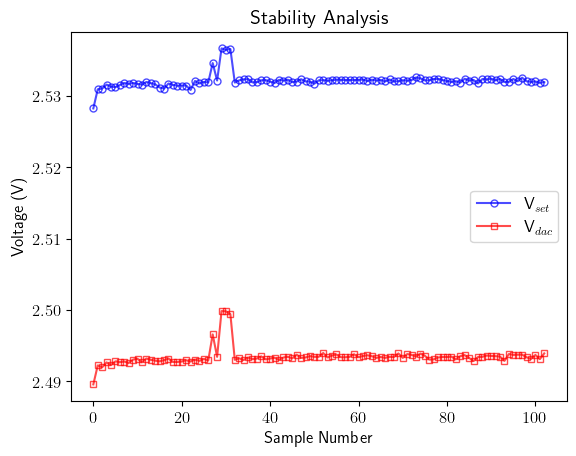

In [5]:
plt.plot(vset, 'b-', marker='o', label='V$_{set}$', ms=5, alpha=0.7, mfc='none')
plt.plot(vdac, 'r-', marker='s', label='V$_{dac}$', ms=5, alpha=0.7, mfc='none')
plt.legend()
plt.xlabel('Sample Number')
plt.ylabel('Voltage (V)')
plt.title('Stability Analysis')

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_195841/2192220982.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.text(10, 40.5, f'Mean ($\mu$): {mean_diff:.2f} mV', fontsize=10,)
/tmp/ipykernel_195841/2192220982.py:13: SyntaxWarning: invalid escape sequence '\s'
  plt.text(10, 40.2, f'Standard Deviation ($\sigma$): {stddev:.2f} mV', fontsize=10,)


Text(0.5, 1.0, '$|$ V$_{dac}$ - V$_{set}$ $|$')

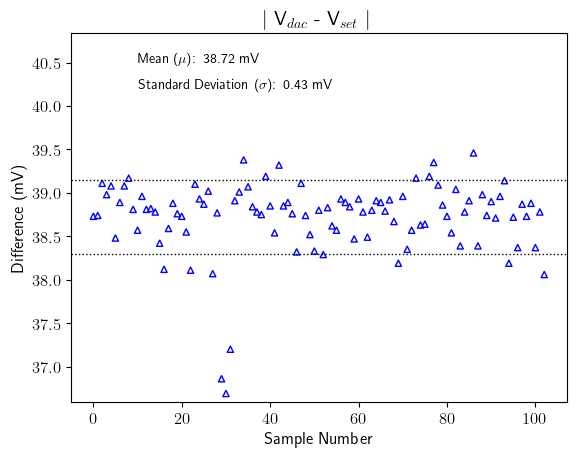

In [6]:
difference = 1000*abs(vdac - vset)
stddev = np.std(difference)
mean_diff = np.mean(difference)
values= list(range(len(vset+1)))
plt.scatter(values, difference, color='b', marker='^', label='$_{dac}$ - $_{set}$', alpha=1.0,fc='none', s=20)
plt.axhline(y=(mean_diff+stddev), color='k', linestyle=':', lw=1.0,)
plt.axhline(y=(mean_diff-stddev), color='k', linestyle=':', lw=1.0,)
n = 5
plt.ylim(mean_diff-n*stddev, mean_diff+n*stddev)
plt.xlabel('Sample Number')
plt.ylabel('Difference (mV)')
plt.text(10, 40.5, f'Mean ($\mu$): {mean_diff:.2f} mV', fontsize=10,)
plt.text(10, 40.2, f'Standard Deviation ($\sigma$): {stddev:.2f} mV', fontsize=10,)
plt.title('$|$ V$_{dac}$ - V$_{set}$ $|$')

## Test across voltages

In [7]:
filename = 'dac_adc_readout.txt'
f = open(filename, 'r')  # Clear the file before writing
lines = [line.split(':') for line in f.readlines()]
f.close()

In [8]:
lines[10], lines[11], lines[12]

(['Vset expected  ', ' 0.11392 V\n'],
 ['Vdac measured  ', ' 0.11175 V\n'],
 ['Vset - Vdac    ', ' 0.00217 V\n'])

In [9]:
vset = []
vdac = []
for line in lines[9:]:
    if line[0] == 'Vset expected  ':
        vset.append(float(line[1].split('V')[0]))
    if line[0] == 'Vdac measured  ':
        vdac.append(float(line[1].split('V')[0]))
vset = np.array(vset)
vdac = np.array(vdac)

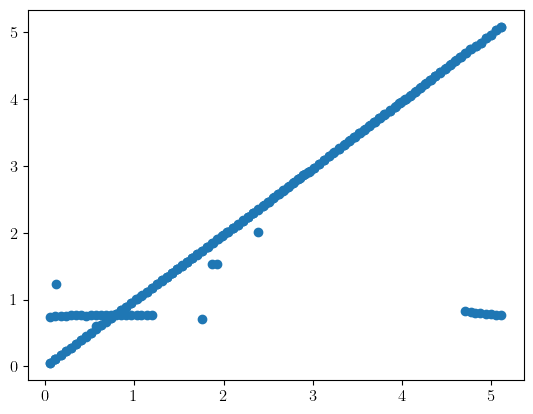

In [11]:
plt.scatter(vset, vdac)

Text(0.5, 1.0, '$|V_{dac} - V_{set}|$ with voltage cycling')

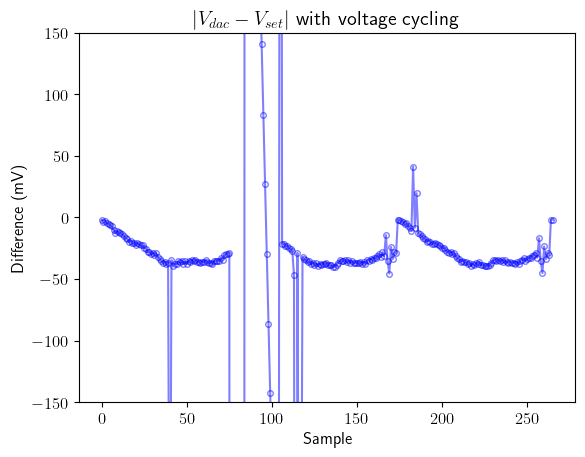

In [60]:
diff = 1000*(vdac - vset)
plt.plot(diff, 'b-', marker='o', label='$V_{dac} - V_{set}$', ms=4, alpha=0.5, mfc='none')
plt.ylim(-150, 150)
plt.xlabel('Sample')
plt.ylabel('Difference (mV)')
plt.title('$|V_{dac} - V_{set}|$ with voltage cycling')

Text(0, 0.5, 'Difference (mV)')

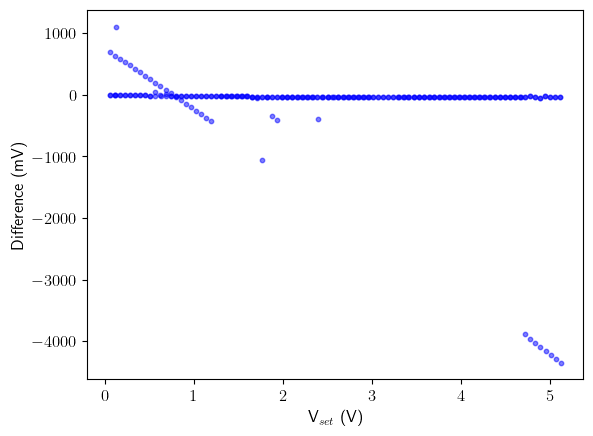

In [ ]:
plt.scatter(vset, diff, s=10, alpha=0.5, color='b')
plt.xlabel('V$_{set}$ (V)')
plt.ylabel('Difference (mV)')

Text(0, 0.5, 'V$_{dac}$ (V)')

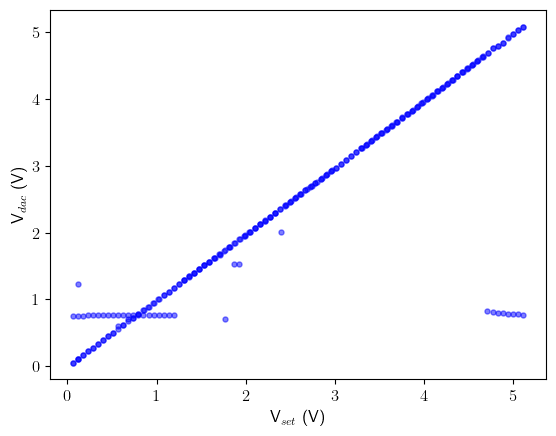

In [74]:
plt.scatter(vset, vdac, s=13, alpha=0.5, color='b')
plt.xlabel('V$_{set}$ (V)')
plt.ylabel('V$_{dac}$ (V)')